In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

Task 1: Data Understanding & Visualization

In [8]:
train_dir ="/content/drive/MyDrive/AI and ML/FruitinAmazon/train"
test_dir ="/content/drive/MyDrive/AI and ML/FruitinAmazon/test"

Classes: ['cupuacu', 'graviola', 'guarana', 'acai', 'pupunha', 'tucuma']


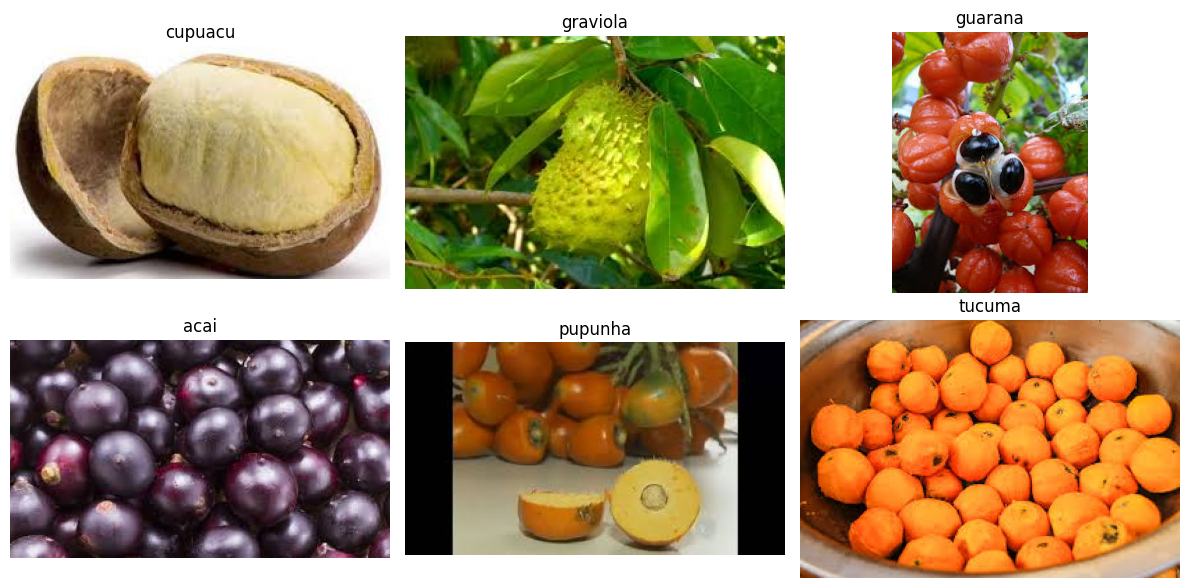

In [9]:
# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image per class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Plot images (2 rows grid)
cols = len(images) // 2 + len(images) % 2

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, cols, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Task 1.2: Check Corrupted Images

In [10]:

corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()   # check if corrupted
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Load & Preprocess Data (Keras)

In [11]:

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: Build CNN Model

In [13]:
num_classes = len(os.listdir(train_dir))

model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and  Train

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    ModelCheckpoint("fruit_cnn_model.h5", save_best_only=True, monitor='val_loss'),
    EarlyStopping(monitor='val_loss', patience=10)
]

print("Model compiled and callbacks are ready!")

Model compiled and callbacks are ready!


In [15]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

print("Training completed!")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.1655 - loss: 1.8262

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 623ms/step - accuracy: 0.1528 - loss: 1.8317 - val_accuracy: 0.0000e+00 - val_loss: 1.9878
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.1794 - loss: 1.7424

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.1944 - loss: 1.7284 - val_accuracy: 0.4444 - val_loss: 1.5841
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.5000 - loss: 1.5256 - val_accuracy: 0.3889 - val_loss: 1.5847
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.4728 - loss: 1.3567

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 0.5278 - loss: 1.2976 - val_accuracy: 0.5000 - val_loss: 1.1530
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.6840 - loss: 1.0153

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 890ms/step - accuracy: 0.7083 - loss: 1.0160 - val_accuracy: 0.7778 - val_loss: 0.9463
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.7216 - loss: 0.8301

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 633ms/step - accuracy: 0.6806 - loss: 0.8552 - val_accuracy: 0.6667 - val_loss: 0.8522
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 0.8750 - loss: 0.5898 - val_accuracy: 0.5556 - val_loss: 1.1333
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8796 - loss: 0.4759

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 521ms/step - accuracy: 0.8889 - loss: 0.4620 - val_accuracy: 0.8889 - val_loss: 0.4110
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.9444 - loss: 0.3077 - val_accuracy: 0.8333 - val_loss: 0.4865
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 0.9861 - loss: 0.1711 - val_accuracy: 0.5000 - val_loss: 1.1480
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 0.9583 - loss: 0.1577 - val_accuracy: 0.8889 - val_loss: 0.5742
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 816ms/step - accuracy: 0.9861 - loss: 0.0987 - val_accuracy: 0.8889 - val_loss: 0.4220
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 1.0000 - loss: 0.0423

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 764ms/step - accuracy: 1.0000 - loss: 0.0451 - val_accuracy: 0.8889 - val_loss: 0.2711
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 1.0000 - loss: 0.0301 - val_accuracy: 0.8889 - val_loss: 0.4508
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 1.0000 - loss: 0.0185 - val_accuracy: 0.8333 - val_loss: 0.6970
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 478ms/step - accuracy: 1.0000 - loss: 0.0189 - val_accuracy: 0.8889 - val_loss: 0.4183
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 541ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.8889 - val_loss: 0.3599
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.8889 - val_loss: 0.3694
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 832ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8889 - val_loss: 0.4155
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 998ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8889 - val_lo

Plot Accuracy & Loss

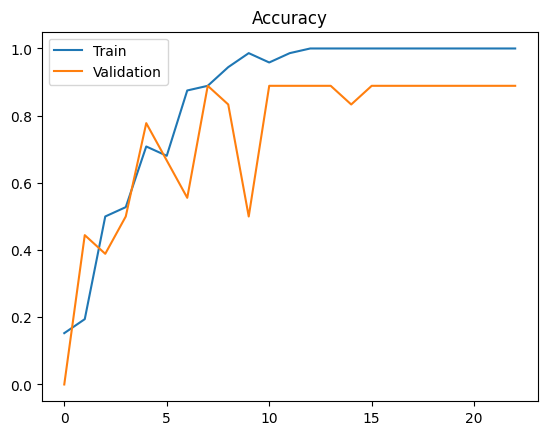

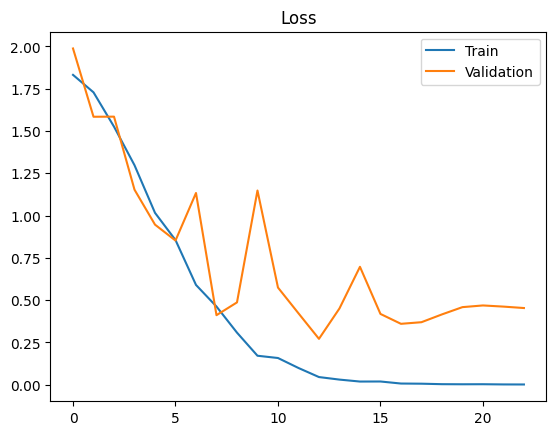

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

Task 5: Evaluate the Model

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.8889 - loss: 0.4532
Test Accuracy: 0.8888888955116272
Test Loss: 0.4531974792480469


Task 6: Save & Load the Model

In [18]:
from tensorflow.keras.models import load_model

# Save the trained model
model.save("fruit_classifier_model.h5")
print("Model saved as fruit_classifier_model.h5")



Model saved as fruit_classifier_model.h5


In [22]:
# Load the saved model
loaded_model = load_model("fruit_classifier_model.h5")
print("Model loaded successfully!")

# Compile the loaded model to properly build metrics
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False # Test data should not be shuffled
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Re-evaluate on test set
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_acc:.4f}")

Model loaded successfully!
Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - accuracy: 0.6667 - loss: 1.0702
Loaded Model Test Loss: 1.0702
Loaded Model Test Accuracy: 0.6667


Task 7: Predictions & Classification Report

In [23]:
import numpy as np
from sklearn.metrics import classification_report

# Lists to store true labels and predictions
y_true = []
y_pred = []

# Loop through test dataset
for images, labels in test_ds:
    preds = loaded_model.predict(images)  # predicted probabilities
    preds = np.argmax(preds, axis=1)      # convert to class labels

    y_true.extend(labels.numpy())         # actual labels
    y_pred.extend(preds)                  # predicted labels

# Print Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
Classification Report:

              precision    recall  f1-score   support

     cupuacu       0.75      0.60      0.67         5
    graviola       0.43      0.60      0.50         5
     guarana       0.62      1.00      0.77         5
        acai       0.80      0.80      0.80         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.71      0.67      0.66        30
weighted avg       0.71      0.67      0.66        30



Worksheet -6

Task - 1

In [24]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [26]:
model = keras.Sequential([

    layers.Input(shape=(128,128,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 4 (Deeper model)
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Fully Connected Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0642 - loss: 2.6076

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.0833 - loss: 2.5553 - val_accuracy: 0.0000e+00 - val_loss: 1.8070
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4444 - loss: 1.6205 - val_accuracy: 0.0000e+00 - val_loss: 1.8693
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.3750 - loss: 1.5487 - val_accuracy: 0.0000e+00 - val_loss: 2.0033
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5139 - loss: 1.3600 - val_accuracy: 0.0000e+00 - val_loss: 2.2038
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.5000 - loss: 1.3052 - val_accuracy: 0.0000e+00 - val_loss: 2.4636
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6111 - loss: 1.0486 - val_accuracy: 0.0000e+00 - val_loss: 2.8123
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6111 - loss: 1.1585 - val_accuracy: 0.0000e+00 - val_loss: 3.1324
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6806 - loss: 0.8746 - val_accuracy: 0.0000e+00 - val_loss: 3

In [28]:
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             

 Total params: 26,741,204 (102.01 MB)

 Trainable params: 8,912,902 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

 Optimizer params: 17,825,806 (68.00 MB)

In [29]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
Classification Report:

              precision    recall  f1-score   support

     cupuacu       0.75      0.60      0.67         5
    graviola       0.43      0.60      0.50         5
     guarana       0.62      1.00      0.77         5
        acai       0.80      0.80      0.80         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.71      0.67      0.66        30
weighted avg       0.71      0.67      0.66        30



Task -2

In [35]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3) # Changed input_shape to match dataset
)

In [36]:
for layer in base_model.layers:
    layer.trainable = False

In [37]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

In [38]:
from tensorflow.keras.models import Model

model = Model(inputs=base_model.input, outputs=x)

In [40]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.0694 - loss: 2.0560 - val_accuracy: 0.3333 - val_loss: 1.7968
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.3750 - loss: 1.5404 - val_accuracy: 0.3333 - val_loss: 1.6551
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.4861 - loss: 1.3206 - val_accuracy: 0.4444 - val_loss: 1.3345
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step - accuracy: 0.6250 - loss: 1.1183 - val_accuracy: 0.6667 - val_loss: 1.1947
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 9s/step - accuracy: 0.8333 - loss: 0.9675 - val_accuracy: 0.6667 - val_loss: 1.0843
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.8056 - loss: 0.8783 - val_accuracy: 0.6667 - val_loss: 0.9129
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.8750 - loss: 0.7109 - val_accuracy: 0.6667 - val_loss: 0.7306
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 7s/step - accuracy: 0.8194 - loss: 0.6546 - val_accuracy: 0.6667 - val_loss: 0.7477
Epoch 9/

In [41]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.8889 - loss: 0.5285
Validation Accuracy: 0.8888888955116272
Validation Loss: 0.5284869074821472


In [42]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())   # for sparse labels
    y_pred.extend(preds)

print("Sample Predictions:", y_pred[:10])

Sample Predictions: [np.int64(4), np.int64(4), np.int64(4), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5)]


In [44]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes, labels=list(range(num_classes))))

Classification Report:

              precision    recall  f1-score   support

     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
        acai       0.00      0.00      0.00         0
     pupunha       0.75      1.00      0.86         3
      tucuma       1.00      0.87      0.93        15

    accuracy                           0.89        18
   macro avg       0.29      0.31      0.30        18
weighted avg       0.96      0.89      0.92        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

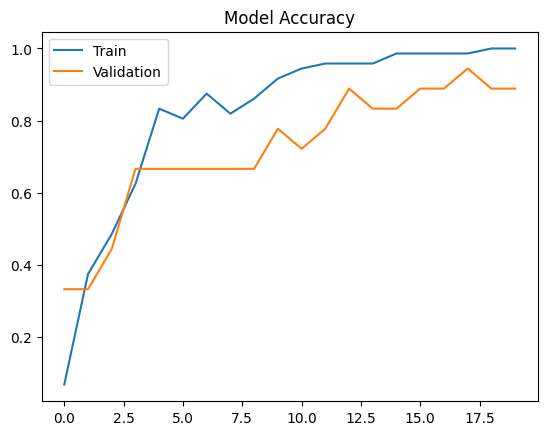

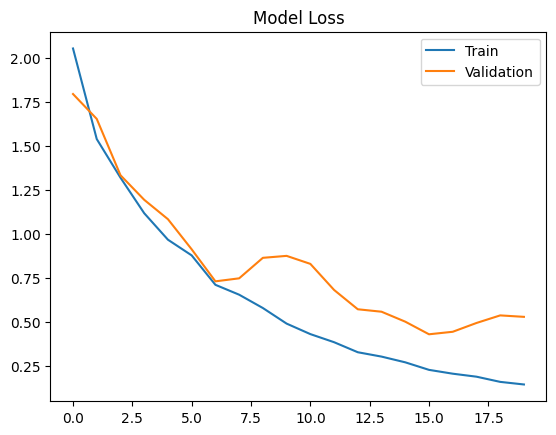

In [45]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()